In [11]:
import pandas as pd
import matplotlib
import sqlite3

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [12]:
df=pd.read_sql(sql='''WITH 
        weekday_commits AS (SELECT 
               DATE(timestamp) AS date, 
               strftime('%H' , timestamp) AS hour,
               COUNT(*) AS commits
        FROM checker
        WHERE uid LIKE 'user_%' AND strftime('%w', timestamp) IN ('1', '2', '3', '4', '5')
        GROUP BY DATE(timestamp), strftime('%H', timestamp)),
               
        weekend_commits AS (SELECT
            DATE(timestamp) AS date,
            strftime('%H' , timestamp) AS hour,
            COUNT(*) AS commits
        FROM checker
        WHERE uid LIKE 'user_%' AND strftime('%w', timestamp) IN ('6', '0')
        GROUP BY DATE(timestamp), strftime('%H', timestamp))
               
    SELECT 'working_day' AS weekday_type, hour, AVG(commits) AS avg_commits FROM weekday_commits
    WHERE commits > 0 GROUP BY hour
    UNION ALL
    SELECT 'weekend' AS weekday_type, hour, AVG(commits) AS avg_commits FROM weekend_commits
    WHERE commits > 0 GROUP BY hour;
               ''', con=connection)
df

,weekday_type,hour,avg_commits
0,working_day,00,3.000000
1,working_day,03,2.000000
2,working_day,05,7.500000
3,working_day,06,1.500000
4,working_day,07,5.166667
5,working_day,08,3.700000
6,working_day,09,6.000000
7,working_day,10,13.200000
8,working_day,11,6.769231
9,working_day,12,7.181818


In [13]:
data = df.pivot(index='hour', columns='weekday_type', values='avg_commits').fillna(0)
data

weekday_type,weekend,working_day
hour,,
00,2.000000,3.000000
01,6.000000,0.000000
03,1.000000,2.000000
05,2.000000,7.500000
06,0.000000,1.500000
07,4.000000,5.166667
08,7.000000,3.700000
09,3.666667,6.000000
10,7.000000,13.200000


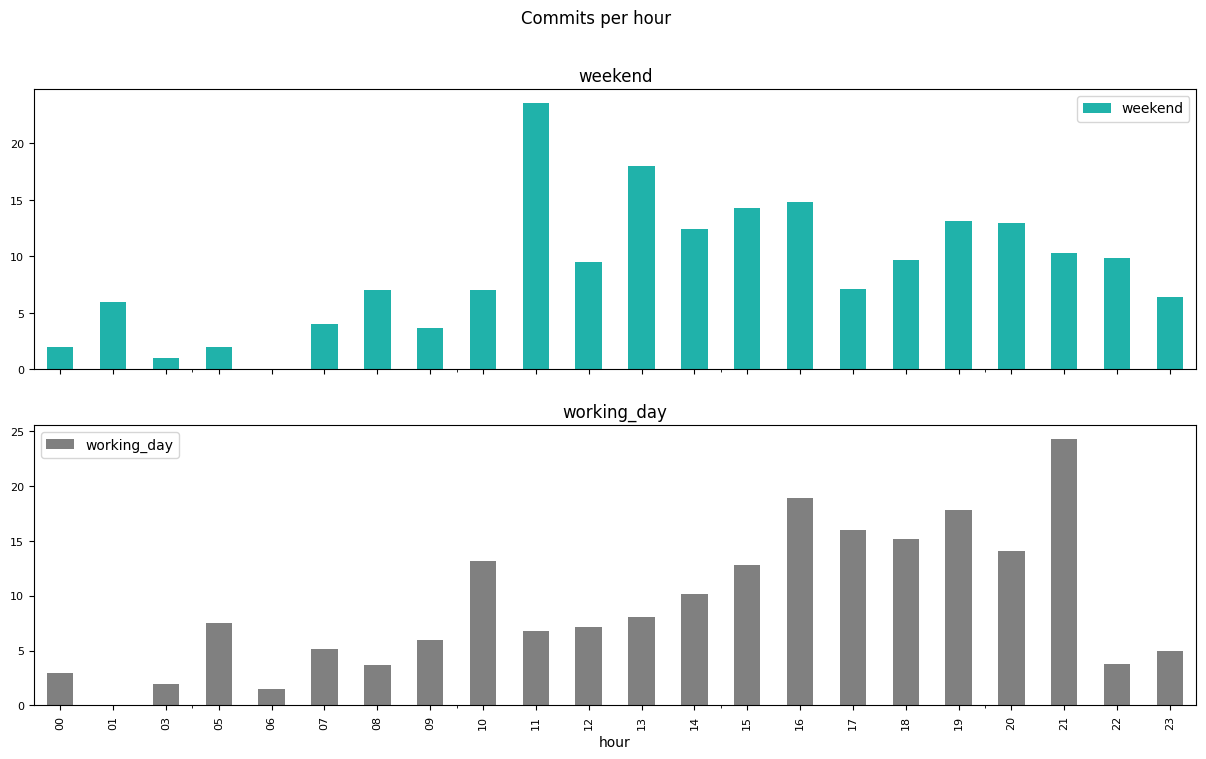

In [14]:
graph=data.plot(kind='bar', subplots=True, figsize=(15,8), fontsize=8, color=['lightseagreen', 'grey'], title='Commits per hour')

In [15]:
connection.close()

«Отличается ли динамика в рабочие и выходные дни?» Для ответа укажите час, когда количество коммитов наибольшее в рабочие дни, и час, когда оно наибольшее в выходные.  
11 в выходные.  
21 в рабочие.